<a href="https://colab.research.google.com/github/wtryab-re/whats-your-eda-basics/blob/main/Outlier_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import n Install

In [49]:
!pip install -q seaborn matplotlib pandas numpy

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [51]:
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
np.random.seed(42)

In [52]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.00,1,0,7.25,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.00,1,0,71.28,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.00,0,0,7.92,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.00,1,0,53.10,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.00,0,0,8.05,S,Third,man,True,NaN,Southampton,no,True


In [53]:
df["survived_label"] = df["survived"].map({0: "No", 1: "Yes"})
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,survived_label
0,0,3,male,22.00,1,0,7.25,S,Third,man,True,NaN,Southampton,no,False,No
1,1,1,female,38.00,1,0,71.28,C,First,woman,False,C,Cherbourg,yes,False,Yes
2,1,3,female,26.00,0,0,7.92,S,Third,woman,False,NaN,Southampton,yes,True,Yes
3,1,1,female,35.00,1,0,53.10,S,First,woman,False,C,Southampton,yes,False,Yes
4,0,3,male,35.00,0,0,8.05,S,Third,man,True,NaN,Southampton,no,True,No


In [54]:
numeric_cols = ["age", "fare", "sibsp", "parch"]
categorical_cols =[]
for col in df.columns:
  if col not in numeric_cols:
    categorical_cols.append(col)
print(categorical_cols)

['survived', 'pclass', 'sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone', 'survived_label']


#Outlier Detection

Visual, statistical, z-score, stat comp w n without outliers

##BOXPLOTS

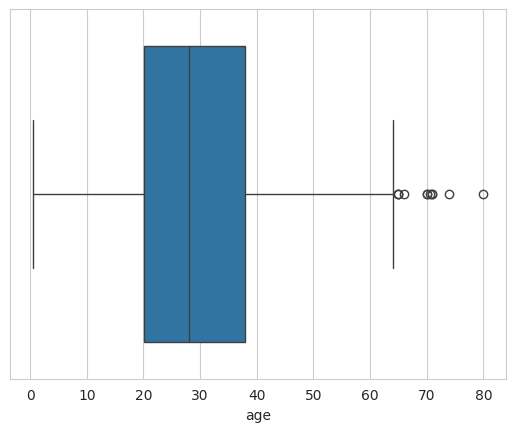

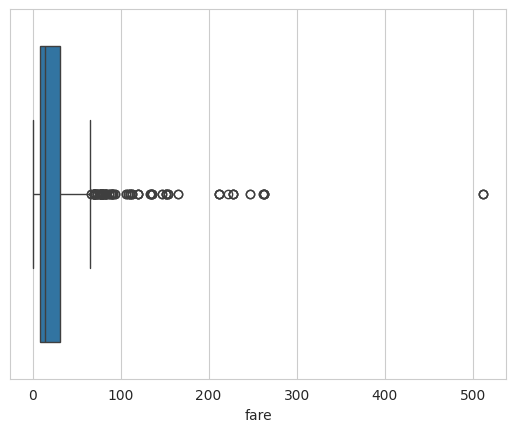

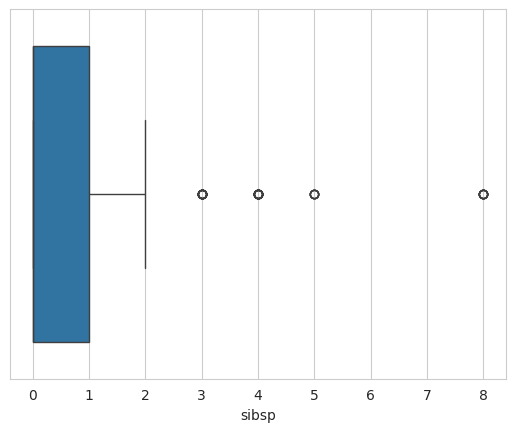

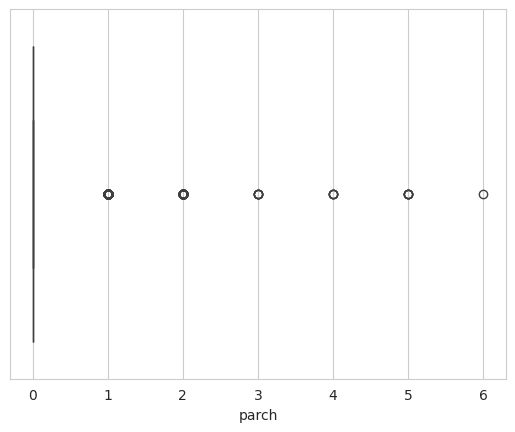

In [55]:
for cols in numeric_cols:
  sns.boxplot(df[cols],orient="y")
  plt.show()

##IQR Method

In [58]:
def outlier_detection(series, factor=1.5):
  Q1 = series.quantile(0.25)
  Q3 = series.quantile(0.75)
  IQR = Q3-Q1
  upper = Q3 + 1.5*IQR
  lower = Q1 - 1.5*IQR
  print("Q1:", Q1)
  print("Q3:", Q3)
  print("Upper:", upper )
  print("Lower:", lower)
  print("IQR:", IQR)
  outliers = series[(series > upper) | (series < lower)]
  return outliers.value_counts().sum()

In [61]:
for col in numeric_cols:
  print(col, outlier_detection(df[col]))

Q1: 20.125
Q3: 38.0
Upper: 64.8125
Lower: -6.6875
IQR: 17.875
age 11
Q1: 7.9104
Q3: 31.0
Upper: 65.6344
Lower: -26.724
IQR: 23.0896
fare 116
Q1: 0.0
Q3: 1.0
Upper: 2.5
Lower: -1.5
IQR: 1.0
sibsp 46
Q1: 0.0
Q3: 0.0
Upper: 0.0
Lower: 0.0
IQR: 0.0
parch 213


##Z-SCORE: -- assumes normal dist
z= value-mean/std

z>3 is outlier

z<3 is outlier

In [62]:
def outlier_detection_zscore(series, factor=3):
  mean = series.mean()
  std = series.std()
  z_val = series.map(lambda x: (x-mean)/std)
  outliers = series[(z_val > factor) | (z_val < -factor)]
  return outliers.value_counts().sum()

In [63]:
for col in numeric_cols:
  print(col)
  print(outlier_detection_zscore(df[col]))

age
2
fare
20
sibsp
30
parch
15


#Stat comparison with and without outliers

In [66]:
fare= df["fare"].dropna()
fare_w_outliers=fare.copy()
fare_clean = fare.copy()

iqr=fare.quantile(0.75)-fare.quantile(0.25)
upper = fare.quantile(0.75) + 1.5*iqr
lower = fare.quantile(0.25) - 1.5*iqr

fare_clean = fare_clean[(fare_clean < upper) & (fare_clean > lower)]

In [68]:
fare_w_outliers.describe()

,fare
count,891.00
mean,32.20
std,49.69
min,0.00
25%,7.91
50%,14.45
75%,31.00
max,512.33


In [67]:
fare_clean.describe()

,fare
count,775.00
mean,17.82
std,13.58
min,0.00
25%,7.90
50%,13.00
75%,26.00
max,65.00


###linear regression, logistic reg and svm assume normal dist